In [191]:
from itertools import accumulate

import math

from triton.experimental.gluon.language import join
from triton.language import tensor

words = open('names.txt', 'r').read().splitlines()

In [192]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [193]:
len(words)

32033

In [194]:
min(len(w) for w in words)

2

In [195]:
max(len(w) for w in words)

15

In [196]:
import torch

In [197]:
N = torch.zeros((27,27), dtype=torch.int32)

In [198]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}

In [199]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1

In [200]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

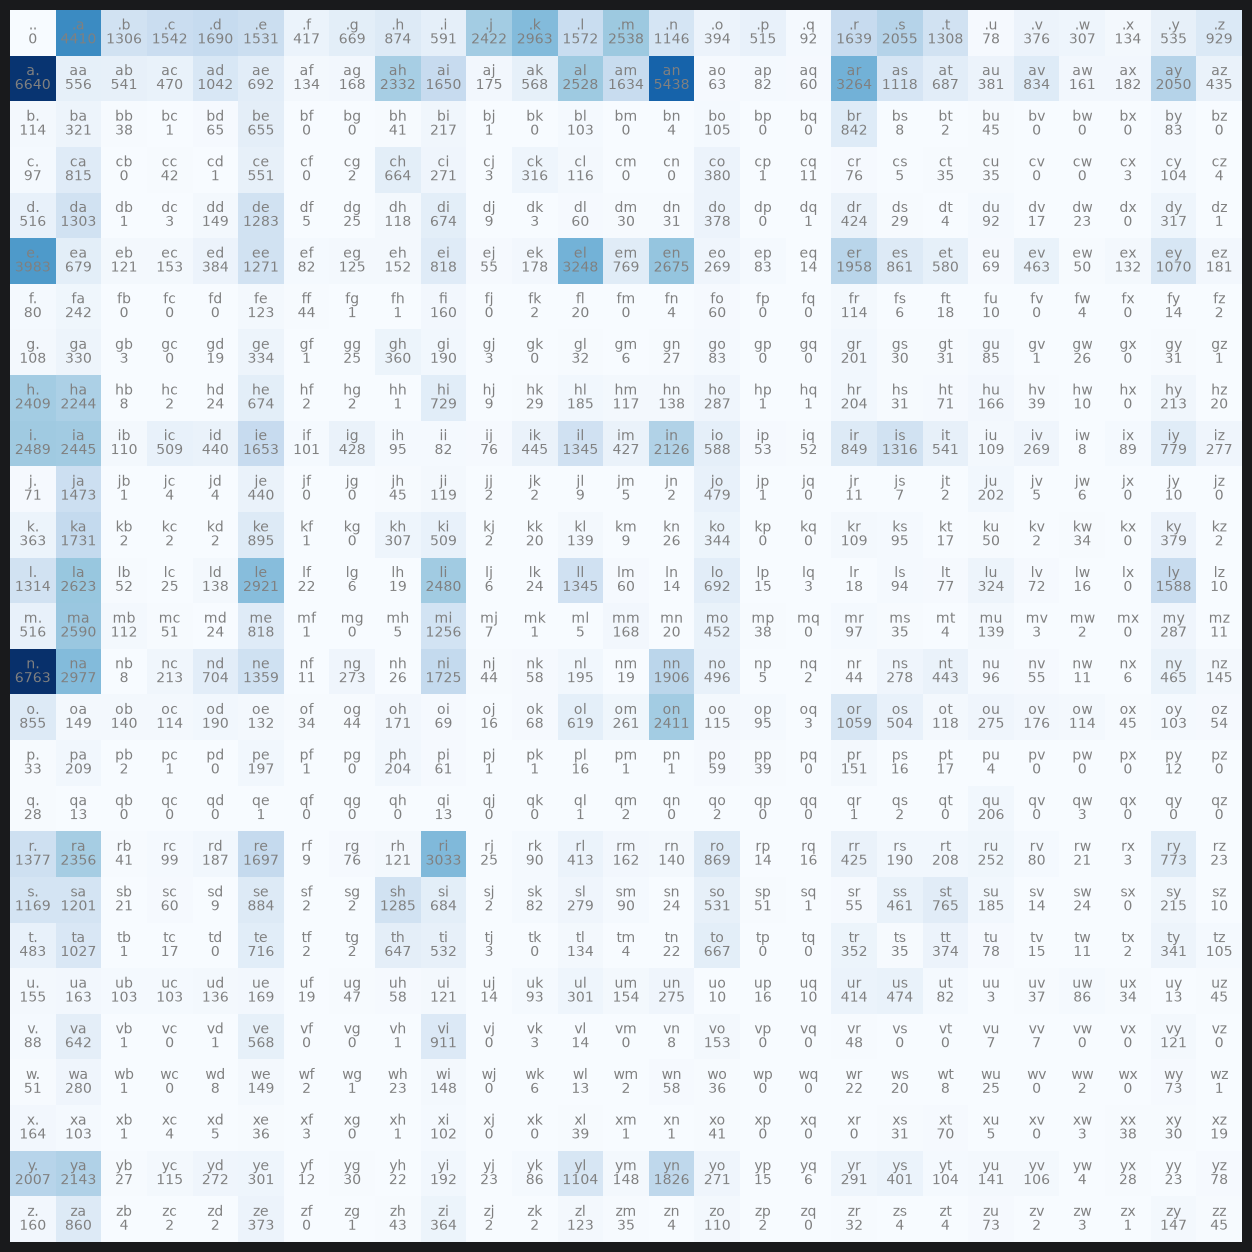

In [201]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [202]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [203]:
g = torch.Generator().manual_seed(21)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

htonki
lyn
erenahary
jeran
avipsmamaes


In [204]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


### The neural network approach

In [205]:
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [206]:
import torch.nn.functional as F

In [207]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [208]:
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
loss = -probs[torch.arange(len(xs)), ys].log().mean()

In [209]:
print(loss.item())

3.758953809738159


In [210]:
W.grad = None
loss.backward()

In [211]:
W.data += -50 * W.grad

In [212]:
for k in range(100):
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    loss = -probs[torch.arange(len(xs)), ys].log().mean()
    print(loss.item())

    W.grad = None
    loss.backward()

    W.data += -50 * W.grad

3.371098518371582
3.1540417671203613
3.020373582839966
2.9277119636535645
2.860402822494507
2.80972957611084
2.7701025009155273
2.7380733489990234
2.711496591567993
2.6890032291412354
2.6696882247924805
2.6529300212860107
2.638277292251587
2.6253881454467773
2.613990545272827
2.603863477706909
2.5948219299316406
2.5867116451263428
2.579403877258301
2.572789192199707
2.5667765140533447
2.5612881183624268
2.5562586784362793
2.551633834838867
2.547365665435791
2.5434155464172363
2.5397486686706543
2.5363364219665527
2.533154249191284
2.5301806926727295
2.5273969173431396
2.5247862339019775
2.522334575653076
2.520029067993164
2.517857789993286
2.515810489654541
2.513878345489502
2.512052059173584
2.5103237628936768
2.5086872577667236
2.5071346759796143
2.5056614875793457
2.504261016845703
2.502929210662842
2.5016605854034424
2.5004522800445557
2.4992990493774414
2.498197317123413
2.4971446990966797
2.496137857437134
2.495173215866089
2.4942495822906494
2.493363380432129
2.4925124645233154


In [214]:
for i in range(5):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)

        ix = torch.multinomial(p, num_samples=1, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

jigla
sadryrolyiniydavesole
rish
be
ka
